In [1]:
import kagglehub

# Download latest version
# download_path = r'C:\Users\ST FRANKLIN PC\Documents\HexSoftwares_Data_Science_Internship'
# path = kagglehub.dataset_download("devzohaib/eligibility-prediction-for-loan")

# print("Path to dataset files:", path)

c:\Users\ST FRANKLIN PC\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
import kagglehub

path = kagglehub.dataset_download("amar5693/student-performance-dataset")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\ST FRANKLIN PC\.cache\kagglehub\datasets\amar5693\student-performance-dataset\versions\1


About Dataset

📊 Student Performance Dataset (5000 Records)

This dataset contains 5000 synthetic student records designed to analyze the relationship between study habits, digital behavior, mental health, and academic performance.


🎯 Dataset Overview

The dataset explores how lifestyle and behavioral factors influence student productivity, burnout levels, focus index, and exam scores.

It includes realistic statistical relationships between variables to simulate real-world student patterns.

📌 Features Included

👤 Demographics

Age

Gender

Academic Level

📚 Study Habits

Study Hours

Self-Study Hours

Online Class Hours

📱 Digital Behavior

Social Media Usage

Gaming Hours

Total Screen Time

🏃 Health & Lifestyle

Sleep Hours

Exercise Minutes

Caffeine Intake

Mental Health Score

⚖ Work & Academic Pressure

Part-Time Job

Upcoming Deadline

Internet Quality


In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [4]:
student_dataset = pd.read_csv('student_productivity_dataset.csv')  

#1 Understanding the data

In [5]:
student_dataset.head()

,student_id,age,gender,academic_level,study_hours,self_study_hours,online_classes_hours,social_media_hours,gaming_hours,sleep_hours,...,exercise_minutes,caffeine_intake_mg,part_time_job,upcoming_deadline,internet_quality,mental_health_score,focus_index,burnout_level,productivity_score,exam_score
0,1,18,Other,High School,7.64,1.56,2.20,3.05,2.19,6.52,...,81,38,1,0,Good,10,43.05,31.77,73.65,50.16
1,2,18,Other,High School,2.21,2.22,2.10,1.65,2.55,5.97,...,111,339,0,0,Good,3,15.92,37.00,13.70,1.00
2,3,22,Male,High School,3.45,0.00,0.29,1.34,2.08,8.39,...,68,266,0,1,Good,8,27.39,34.37,45.15,18.30
3,4,17,Other,High School,5.75,2.08,3.01,2.27,2.20,6.31,...,113,480,1,1,Poor,3,22.31,77.31,20.92,9.37
4,5,19,Other,High School,6.83,1.72,3.33,2.65,0.70,8.01,...,121,24,1,0,Good,8,38.11,39.53,59.23,27.81


In [6]:
student_dataset.tail()

,student_id,age,gender,academic_level,study_hours,self_study_hours,online_classes_hours,social_media_hours,gaming_hours,sleep_hours,...,exercise_minutes,caffeine_intake_mg,part_time_job,upcoming_deadline,internet_quality,mental_health_score,focus_index,burnout_level,productivity_score,exam_score
4995,4996,20,Other,Undergraduate,3.93,1.42,0.54,2.58,2.62,9.30,...,113,496,0,0,Good,9,35.55,33.24,48.83,22.51
4996,4997,24,Male,High School,4.00,0.00,3.00,4.45,2.47,6.42,...,146,411,0,1,Poor,5,16.87,59.07,23.32,2.00
4997,4998,22,Male,Undergraduate,5.63,2.52,2.89,3.58,1.07,6.65,...,123,306,0,1,Good,7,23.85,47.72,41.09,27.89
4998,4999,17,Male,Undergraduate,3.58,2.83,1.53,5.88,1.28,7.36,...,54,304,1,1,Good,4,13.04,58.90,12.62,3.63
4999,5000,22,Other,Undergraduate,5.60,4.14,2.17,3.05,2.74,6.38,...,24,219,0,1,Good,3,29.98,61.01,34.72,10.76


In [7]:
student_dataset.shape

(5000, 21)

In [8]:
student_dataset.describe()

,student_id,age,study_hours,self_study_hours,online_classes_hours,social_media_hours,gaming_hours,sleep_hours,screen_time_hours,exercise_minutes,caffeine_intake_mg,part_time_job,upcoming_deadline,mental_health_score,focus_index,burnout_level,productivity_score,exam_score
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,2500.500000,20.520400,4.539594,2.478734,2.011984,2.998086,1.564514,7.016492,6.979588,74.535600,251.450400,0.498200,0.501400,5.507400,29.431616,45.615324,37.267716,18.803752
std,1443.520003,2.870406,1.821665,1.177990,0.983906,1.467949,1.110807,1.163692,2.486214,42.932293,143.842712,0.500047,0.500048,2.869145,9.962902,14.246591,16.849397,12.130840
min,1.000000,16.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,1250.750000,18.000000,3.250000,1.660000,1.320000,1.990000,0.670000,6.237500,5.280000,37.000000,129.000000,0.000000,0.000000,3.000000,22.567500,35.727500,25.290000,9.337500
50%,2500.500000,20.000000,4.530000,2.480000,2.010000,2.980000,1.490000,7.010000,6.950000,75.000000,252.000000,0.000000,1.000000,5.000000,29.430000,45.690000,36.860000,18.010000
75%,3750.250000,23.000000,5.760000,3.290000,2.690000,4.030000,2.340000,7.810000,8.710000,112.000000,376.000000,1.000000,1.000000,8.000000,36.242500,55.352500,49.142500,27.400000
max,5000.000000,25.000000,11.840000,7.410000,6.000000,8.280000,5.640000,10.000000,15.300000,149.000000,499.000000,1.000000,1.000000,10.000000,63.480000,97.580000,98.020000,64.090000


In [9]:
student_dataset.columns

Index(['student_id', 'age', 'gender', 'academic_level', 'study_hours',
       'self_study_hours', 'online_classes_hours', 'social_media_hours',
       'gaming_hours', 'sleep_hours', 'screen_time_hours', 'exercise_minutes',
       'caffeine_intake_mg', 'part_time_job', 'upcoming_deadline',
       'internet_quality', 'mental_health_score', 'focus_index',
       'burnout_level', 'productivity_score', 'exam_score'],
      dtype='str')

In [10]:
student_dataset.nunique() #Check unique values

student_id              5000
age                       10
gender                     3
academic_level             3
study_hours              840
self_study_hours         552
online_classes_hours     462
social_media_hours       662
gaming_hours             463
sleep_hours              559
screen_time_hours       1089
exercise_minutes         150
caffeine_intake_mg       500
part_time_job              2
upcoming_deadline          2
internet_quality           3
mental_health_score       10
focus_index             2773
burnout_level           3256
productivity_score      3410
exam_score              2743
dtype: int64

In [11]:
student_dataset['gender'].unique() #Check each column unique values

<StringArray>
['Other', 'Male', 'Female']
Length: 3, dtype: str

#Cleaning the data

In [12]:
student_dataset.isnull().sum()

student_id              0
age                     0
gender                  0
academic_level          0
study_hours             0
self_study_hours        0
online_classes_hours    0
social_media_hours      0
gaming_hours            0
sleep_hours             0
screen_time_hours       0
exercise_minutes        0
caffeine_intake_mg      0
part_time_job           0
upcoming_deadline       0
internet_quality        0
mental_health_score     0
focus_index             0
burnout_level           0
productivity_score      0
exam_score              0
dtype: int64

In [13]:
# new_student_dataset = student_dataset.drop(['student_id', 'age', 'gender', 'academic_level', 'self_study_hours', 'online_classes_hours', 'social_media_hours', 'gaming_hours', 'caffeine_intake_mg', 'part_time_job', 'upcoming_deadline', 'internet_quality'], axis=1)

#3 Relationship analysis

In [14]:
#Define group

study_habits = ['study_hours', 'self_study_hours', 'online_classes_hours']

digital_behavior = ['social_media_hours', 'gaming_hours', 'screen_time_hours']

mental_health = ['mental_health_score', 'burnout_level', 'sleep_hours']

academic_performance = ['exam_score', 'productivity_score', 'focus_index']

In [15]:
#Study Habits vs Academic Performance
study_corr = student_dataset[study_habits + academic_performance].corr()
study_vs_perf = study_corr.loc[study_habits, academic_performance]
study_vs_perf

,exam_score,productivity_score,focus_index
study_hours,0.513434,0.637981,0.448050
self_study_hours,0.083602,0.057781,0.237721
online_classes_hours,0.004975,0.003215,0.007709


In [16]:
#Digital Behavior vs Academic Performance
digital_corr = student_dataset[digital_behavior + academic_performance].corr()
digital_vs_perf = digital_corr.loc[digital_behavior, academic_performance]
digital_vs_perf

,exam_score,productivity_score,focus_index
social_media_hours,-0.106116,-0.070052,-0.314478
gaming_hours,-0.054506,-0.029411,-0.176751
screen_time_hours,-0.131940,-0.089953,-0.008281


In [17]:
#Mental Health vs Academic Performance
mental_corr = student_dataset[mental_health + academic_performance].corr()
mental_vs_perf = mental_corr.loc[mental_health, academic_performance]
mental_vs_perf


,exam_score,productivity_score,focus_index
mental_health_score,0.546547,0.630605,0.575864
burnout_level,-0.407808,-0.267304,-0.075425
sleep_hours,0.234710,0.149666,0.158236


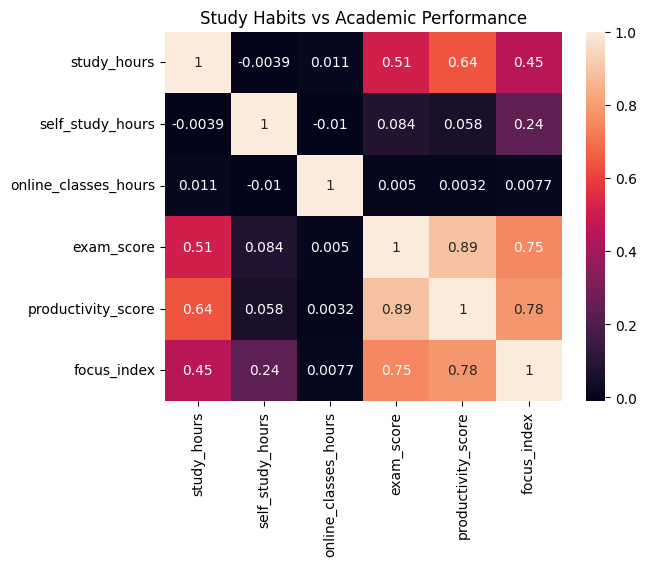

In [18]:
sns.heatmap(study_corr, xticklabels=study_corr.columns, yticklabels=study_corr.columns, annot=True)
plt.title("Study Habits vs Academic Performance")
plt.show()

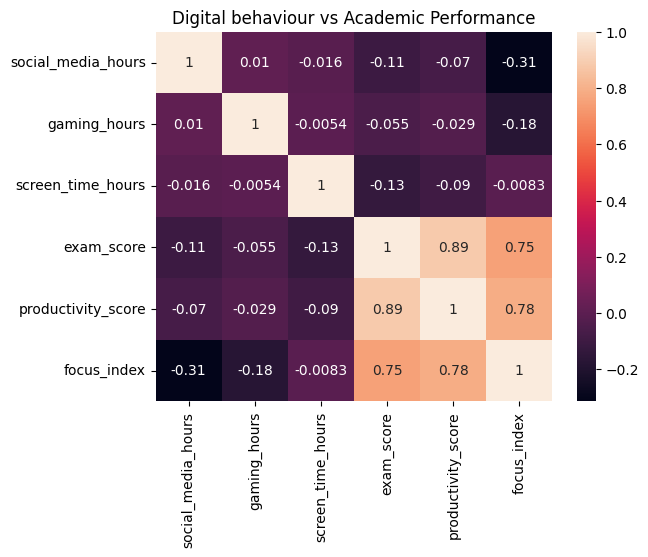

In [19]:
sns.heatmap(digital_corr, xticklabels=digital_corr.columns, yticklabels=digital_corr.columns, annot=True)
plt.title("Digital behaviour vs Academic Performance")
plt.show()

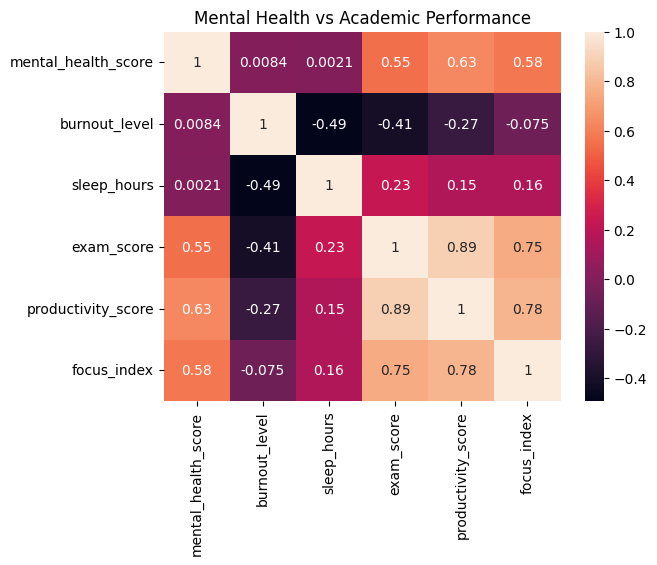

In [20]:
sns.heatmap(mental_corr, xticklabels=mental_corr.columns, yticklabels=mental_corr.columns, annot=True)
plt.title("Mental Health vs Academic Performance")
plt.show()

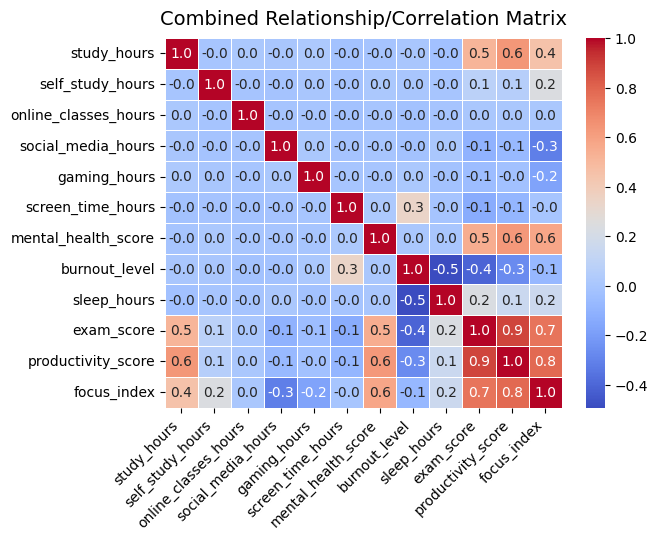

In [21]:
all_corr = student_dataset[study_habits + digital_behavior + mental_health + academic_performance].corr()
sns.heatmap(all_corr, xticklabels=all_corr.columns, yticklabels=all_corr.columns, annot=True, fmt=".1f", linewidths=0.5, cmap="coolwarm")
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.title("Combined Relationship/Correlation Matrix", fontsize=14, pad=10)
plt.show()

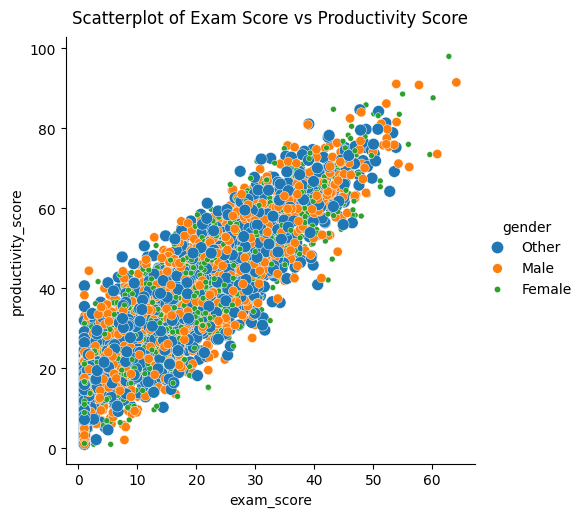

In [22]:
#Relationship plot
sns.relplot(x='exam_score' , y='productivity_score' , hue='gender', size='gender', data=student_dataset, kind='scatter')
plt.title("Scatterplot of Exam Score vs Productivity Score", fontsize=12, pad=10)
plt.show()


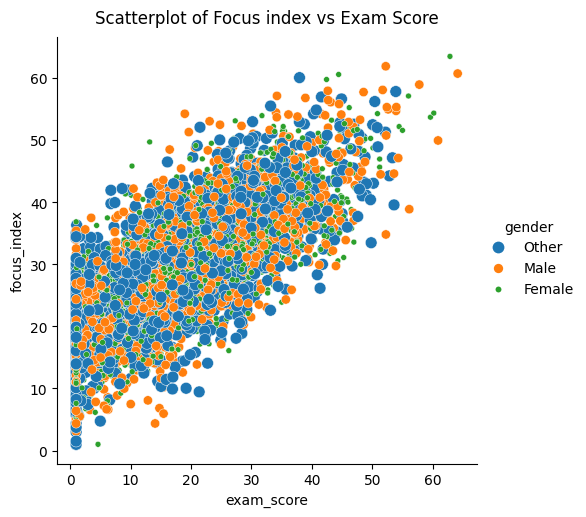

In [25]:
sns.relplot(x='exam_score' , y='focus_index' , hue='gender', size='gender', data=student_dataset, kind='scatter')
plt.title("Scatterplot of Focus index vs Exam Score", fontsize=12, pad=10)
plt.show()


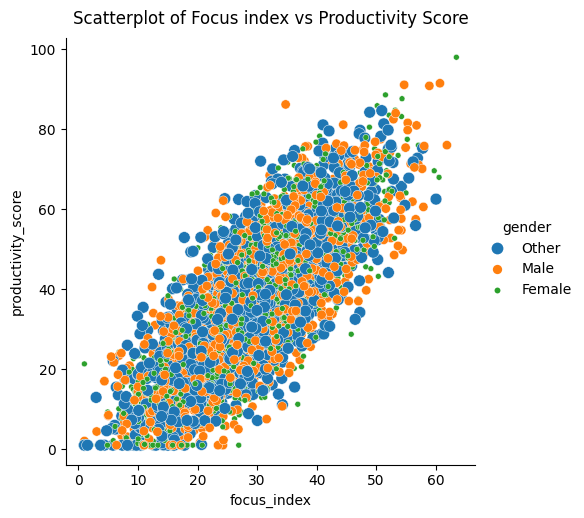

In [26]:
sns.relplot(x='focus_index' , y='productivity_score' , hue='gender', size='gender', data=student_dataset, kind='scatter')
plt.title("Scatterplot of Focus index vs Productivity Score", fontsize=12, pad=10)
plt.show()
